# EDA Capstone — Titanic

In dit project voer je een **volledige exploratieve data-analyse** uit op de Titanic-dataset — van het laden van de data tot het formuleren van betekenisvolle inzichten.

Je past alle technieken toe die je in de vorige notebooks leerde:
- Laden en inspecteren
- Ontbrekende waarden analyseren
- Opschonen
- Univariate analyse (distributies, uitschieters)
- Bivariate en multivariate analyse (correlaties, relaties met de doelvariabele)
- Inzichten samenvatten

⚠️ Dit is **puur exploratief** — geen modellen, geen training. Het doel is om de data te begrijpen.

---

**Doelvariabele:** `survived` (0 = niet overleefd, 1 = overleefd)

**Onderzoeksvraag:** *Welke kenmerken hangen samen met de kans op overleven van de ramp?*

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

df_raw = sns.load_dataset("titanic")
print(f"Dataset: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
df_raw.head()

Dataset: 891 rows × 15 columns


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 1. Eerste verkenning

In [2]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [3]:
df_raw.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
survived,891.0,0.38,0.49,0.00,0.00,0.00,1.0,1.00
pclass,891.0,2.31,0.84,1.00,2.00,3.00,3.0,3.00
age,714.0,29.70,14.53,0.42,20.12,28.00,38.0,80.00
sibsp,891.0,0.52,1.10,0.00,0.00,0.00,1.0,8.00
parch,891.0,0.38,0.81,0.00,0.00,0.00,0.0,6.00
fare,891.0,32.20,49.69,0.00,7.91,14.45,31.0,512.33


## 2. Ontbrekende waarden

In [4]:
missing = pd.DataFrame(
    {
        "n_missing": df_raw.isnull().sum(),
        "pct_missing": (df_raw.isnull().mean() * 100).round(1),
    }
)
missing[missing["n_missing"] > 0].sort_values("pct_missing", ascending=False)

,n_missing,pct_missing
deck,688,77.2
age,177,19.9
embarked,2,0.2
embark_town,2,0.2


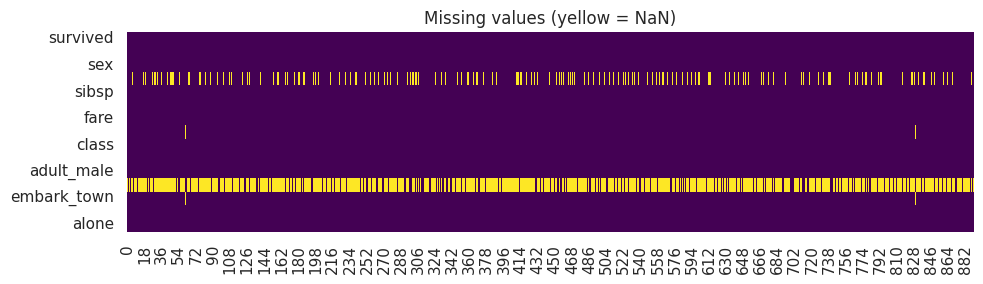

In [5]:
fig, ax = plt.subplots(figsize=(10, 3))
sns.heatmap(df_raw.isnull().T, cbar=False, cmap="viridis", ax=ax)
ax.set_title("Missing values (yellow = NaN)")
plt.tight_layout()
plt.show()

**Bevinding:**

> *De kolom `deck` heeft meer dan 77% ontbrekende waarden en is niet bruikbaar voor analyse. `age` heeft ~20% missende waarden en wordt opgevuld met de mediaan. `embarked` heeft slechts 2 missende waarden.*

## 3. Opschonen

In [6]:
df = df_raw.copy()

# Drop columns with > 50% NaN or redundant columns
df = df.drop(columns=["deck", "embark_town", "alive", "who", "adult_male"])

# Fill age with median
df["age"] = df["age"].fillna(df["age"].median())

# Fill embarked with mode
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

# Cast passenger class to category
df["pclass"] = df["pclass"].astype("category")

print("Missing values after cleaning:")
print(df.isnull().sum())
print(f"\nShape: {df.shape}")

Missing values after cleaning:
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
class       0
alone       0
dtype: int64

Shape: (891, 10)


## 4. Univariate analyse

### 4a. Doelvariabele: `survived`

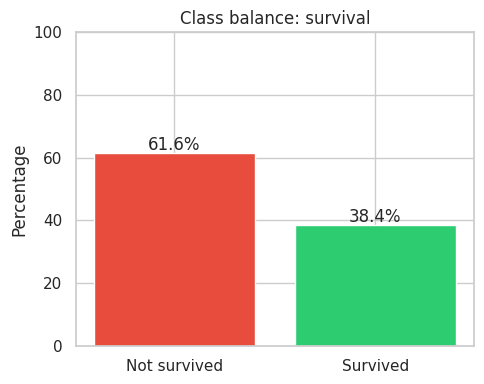

Survival rate: 38.4%


In [7]:
survival_rate = df["survived"].value_counts(normalize=True).round(3) * 100

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(
    ["Not survived", "Survived"],
    survival_rate.values,
    color=["#e74c3c", "#2ecc71"],
    edgecolor="white",
)
for i, v in enumerate(survival_rate.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=12)
ax.set_ylim(0, 100)
ax.set_title("Class balance: survival")
ax.set_ylabel("Percentage")
plt.tight_layout()
plt.show()

print(f"Survival rate: {survival_rate[1]:.1f}%")

### 4b. Numerieke variabelen

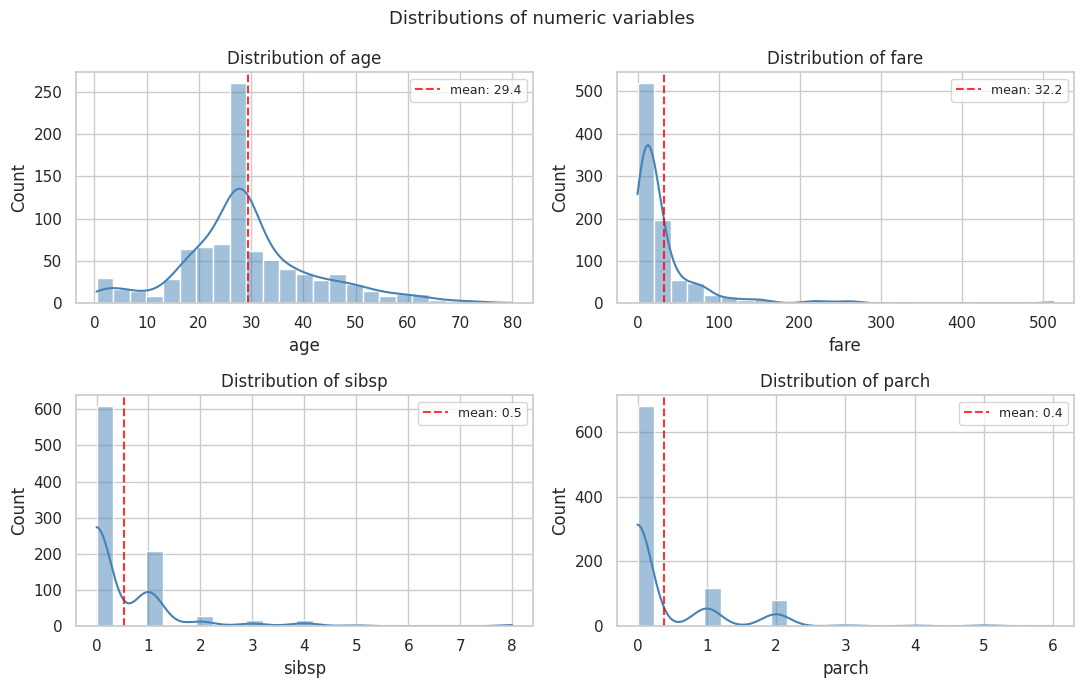

In [8]:
numeric_columns = ["age", "fare", "sibsp", "parch"]

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes = axes.flatten()

for ax, column in zip(axes, numeric_columns):
    data = df[column].dropna()
    sns.histplot(data, bins=25, kde=True, ax=ax, color="steelblue")
    ax.axvline(
        data.mean(), color="red", linestyle="--", alpha=0.8, label=f"mean: {data.mean():.1f}"
    )
    ax.set_title(f"Distribution of {column}")
    ax.legend(fontsize=9)

plt.suptitle("Distributions of numeric variables", fontsize=13)
plt.tight_layout()
plt.show()

### 4c. Categorische variabelen

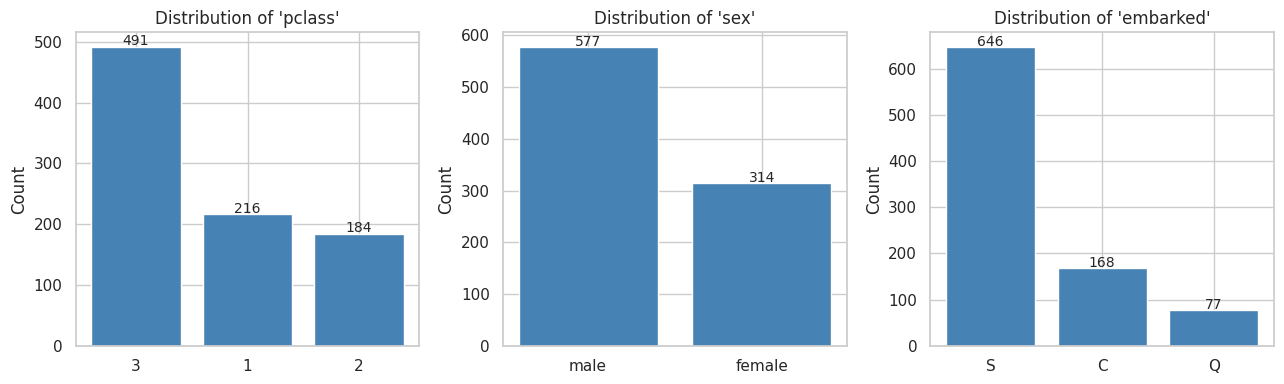

In [9]:
cat_columns = ["pclass", "sex", "embarked"]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, column in zip(axes, cat_columns):
    counts = df[column].value_counts()
    ax.bar(counts.index.astype(str), counts.values, color="steelblue", edgecolor="white")
    ax.set_title(f"Distribution of '{column}'")
    ax.set_ylabel("Count")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 3, str(v), ha="center", fontsize=10)

plt.tight_layout()
plt.show()

## 5. Bivariate analyse — relaties met `survived`

### 5a. Correlatiematrix

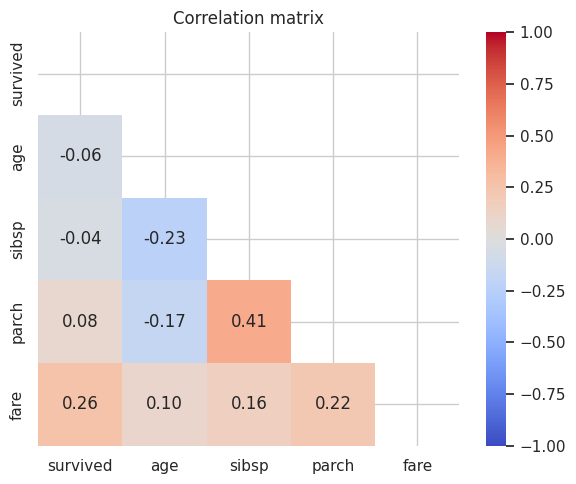

In [10]:
corr = df.select_dtypes(include="number").corr().round(2)

fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation matrix")
plt.tight_layout()
plt.show()

### 5b. Geslacht en klasse — de sterkste predictoren

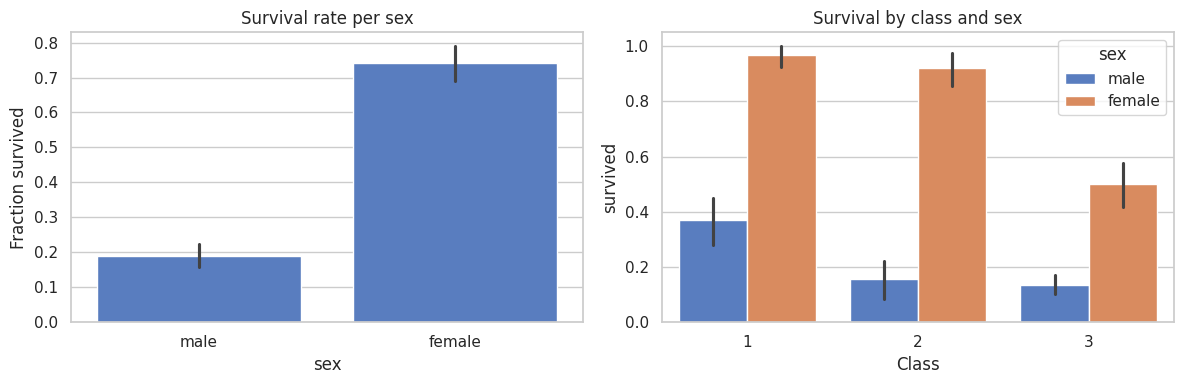

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=df, x="sex", y="survived", ax=axes[0])
axes[0].set_title("Survival rate per sex")
axes[0].set_ylabel("Fraction survived")

sns.barplot(data=df, x="pclass", y="survived", hue="sex", ax=axes[1])
axes[1].set_title("Survival by class and sex")
axes[1].set_xlabel("Class")

plt.tight_layout()
plt.show()

### 5c. Leeftijdsverdeling per overlevingsstatus

In [12]:
fig = px.histogram(
    df,
    x="age",
    color=df["survived"].map({0: "Not survived", 1: "Survived"}),
    nbins=30,
    barmode="overlay",
    opacity=0.7,
    title="Age distribution per survival status",
    labels={"age": "Age (years)", "count": "Count", "color": "Status"},
    color_discrete_map={"Not survived": "#e74c3c", "Survived": "#2ecc71"},
)
fig.show()

### 5d. Ticketprijs per klasse

In [13]:
fig = px.box(
    df,
    x="pclass",
    y="fare",
    color=df["survived"].map({0: "Not survived", 1: "Survived"}),
    points="outliers",
    title="Ticket prices per class and survival status",
    labels={"pclass": "Class", "fare": "Price (£)", "color": "Status"},
    color_discrete_map={"Not survived": "#e74c3c", "Survived": "#2ecc71"},
)
fig.show()

### 5e. Pairplot

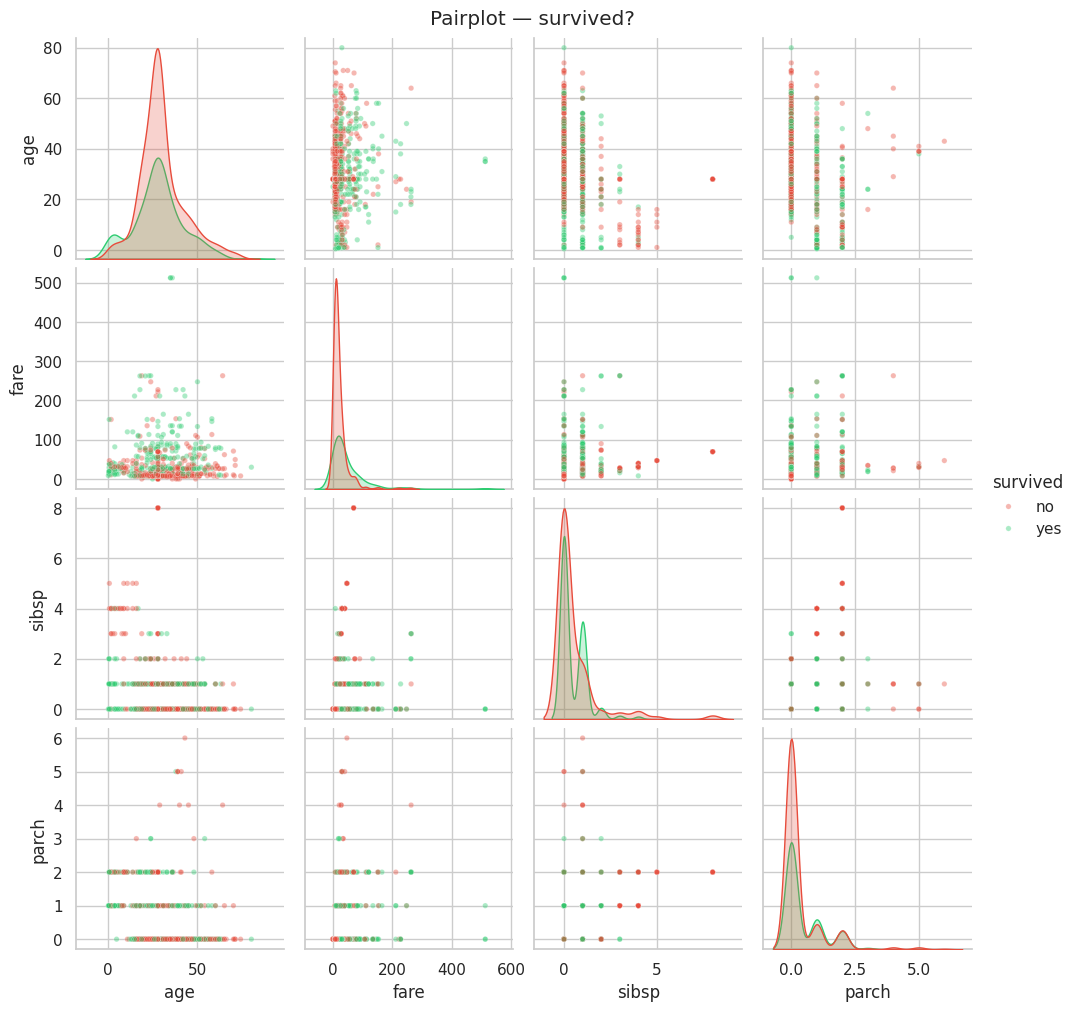

In [14]:
subset = df[["survived", "age", "fare", "sibsp", "parch"]].copy()
subset["survived"] = subset["survived"].map({0: "no", 1: "yes"})

g = sns.pairplot(
    subset,
    hue="survived",
    plot_kws={"alpha": 0.4, "s": 15},
    palette={"no": "#e74c3c", "yes": "#2ecc71"},
)
g.fig.suptitle("Pairplot — survived?", y=1.01)
plt.show()

## 6. Samenvatting van bevindingen

Vul hieronder de bevindingen in op basis van je analyse.

### Dataset
- De dataset bevat **891 passagiers** met **8 relevante kenmerken** na opkuisen.
- **38,4%** van de passagiers overleefde de ramp — de dataset is **onevenwichtig**.

### Ontbrekende waarden
- `deck`: 77% NaN → **verwijderd**
- `age`: 20% NaN → **opgevuld met mediaan (28 jaar)**
- `embarked`: 2 NaN → opgevuld met modus

### Belangrijkste bevindingen

| Bevinding | Visualisatie |
|---|---|
| **Geslacht** is de sterkste predictor: vrouwen overleefden in ~74% van de gevallen, mannen slechts in ~19% | Barplot sex vs. survived |
| **Klasse** heeft een sterk effect: passagiers in eerste klas overleefden veel vaker | Barplot class vs. survived |
| **Leeftijd**: kinderen (< 10 jaar) hadden een hogere overlevingskans | Histogram per status |
| **Ticketprijs** correleert positief met overleven — hogere prijs = hogere kans | Boxplot fare |
| `sibsp` en `parch` (familieleden) tonen een zwakke negatieve correlatie met overleven bij grote aantallen | Pairplot / correlatiematrix |

### Volgende stap
De dataset is nu klaar voor verdere analyse in de ML-notebooks.

---

## Oefeningen

Herhaal de bovenstaande analyse voor de **Penguins-dataset** (`sns.load_dataset("penguins")`). Gebruik de structuur hierboven als template:

1. Laden en inspecteren
2. Ontbrekende waarden analyseren
3. Opkuisen
4. Univariate analyse (distributies, categorische verdeling)
5. Bivariate analyse (correlatieheatmap, relaties met `species`)
6. Samenvatting in markdown

**Onderzoeksvraag:** *Welke kenmerken onderscheiden de drie pinguïnsoorten het best?*

In [15]:
penguins = sns.load_dataset("penguins")
# Add your EDA in the cells below

In [16]:
# 1. Inspect the dataset

In [17]:
# 2. Missing values

In [18]:
# 3. Clean

In [19]:
# 4. Univariate analysis

In [20]:
# 5. Bivariate analysis

Bevindingen ...
